In [3]:
import json
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [4]:
files = glob.glob("../data/parsed/*.json")

prs = []
chs = []
sec = []
art = []
cla = []
pts = []

for f in files:
    with open(f, "r", encoding="utf-8") as file:
        data = json.load(file)
        nodes = data["nodes"]
        for pa in nodes["parts"]:
            prs.append(pa)
        for ch in nodes["chapters"]:
            chs.append(ch)
        for se in nodes["sections"]:
            sec.append(se)
        for ar in nodes["articles"]:
            art.append(ar)
        for cl in nodes["clauses"]:
            cla.append(cl)
        for pt in nodes["points"]:
            pts.append(pt)

parts = pd.DataFrame(prs)
chapters = pd.DataFrame(chs)
sections = pd.DataFrame(sec)
articles = pd.DataFrame(art)
clauses = pd.DataFrame(cla)
points = pd.DataFrame(pts)

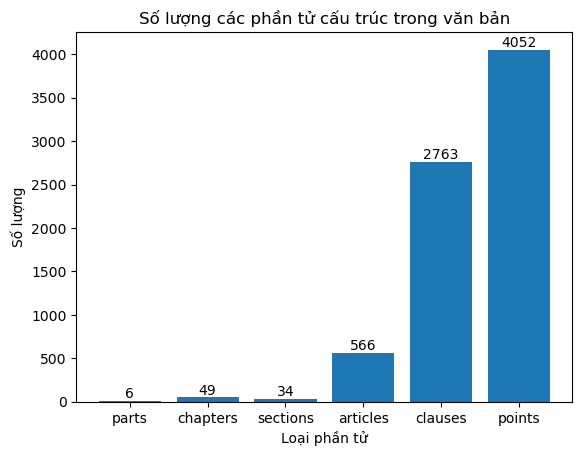

In [5]:
counts = {
    "parts": len(parts),
    "chapters": len(chapters),
    "sections": len(sections),
    "articles": len(articles),
    "clauses": len(clauses),
    "points": len(points)
}
labels = list(counts.keys())
values = list(counts.values())
bars = plt.bar(labels, values)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(int(height)),
             ha='center', va='bottom')
plt.title("Số lượng các phần tử cấu trúc trong văn bản")
plt.xlabel("Loại phần tử")
plt.ylabel("Số lượng")
plt.show()

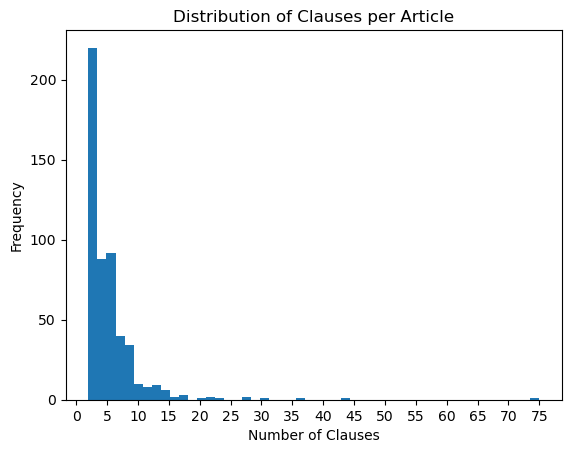

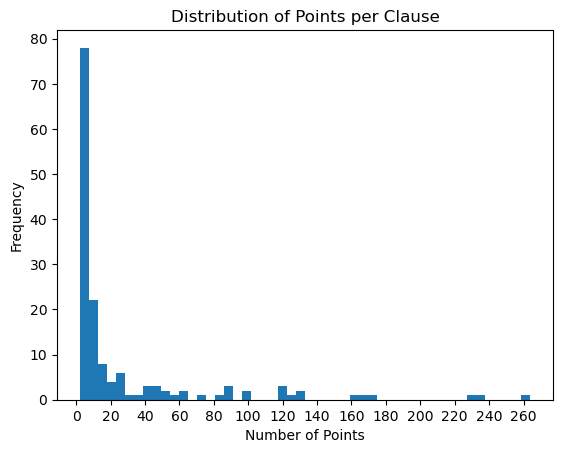

In [6]:
clause_count = clauses.groupby(["doc_identity", "parent_article"]).size()
plt.hist(clause_count, bins=50)
plt.gca().xaxis.set_major_locator(MultipleLocator(5))
plt.title("Distribution of Clauses per Article")
plt.xlabel("Number of Clauses")
plt.ylabel("Frequency")
plt.show()
point_count = points.groupby(["doc_identity", "parent_clause"]).size()
plt.hist(point_count, bins=50)
plt.gca().xaxis.set_major_locator(MultipleLocator(20))
plt.title("Distribution of Points per Clause")
plt.xlabel("Number of Points")
plt.ylabel("Frequency")
plt.show()

In [7]:
text_cols = [
    "content",
    "title",
]
texts = []

for col in text_cols:
    for df in [parts, chapters, sections, articles, clauses, points]:
        if col in df:
            texts.extend(
                [x for x in df[col].dropna().astype(str) if x.strip() != ""]
            )

len(texts)

7536

In [8]:
all_text = " ".join(texts)
len(all_text)

1587950

In [9]:
with open("vietnamese-stopwords.txt", encoding="utf-8") as f:
    stopwords = set(f.read().splitlines())

In [10]:
from underthesea import word_tokenize
import re
tokens = []
for text in texts:
    tk = word_tokenize(text)
    tk = [t for t in tk if re.match(r'\w+', t)]
    tk = [t for t in tk if t not in stopwords]
    tokens.extend(tk)
len(tokens)

155916

In [11]:
len(set(tokens))

4404

In [12]:
len(set(tokens))/len(tokens)

0.02824597860386362

In [13]:
df_text = pd.DataFrame({
    "content": texts
})
df_text["tokens"] = df_text["content"].apply(lambda x: word_tokenize(x))
df_text["length"] = df_text["tokens"].apply(len)
df_text.head()

,content,tokens,length
0,\nNHỮNG QUY ĐỊNH CHUNG,"[NHỮNG, QUY ĐỊNH, CHUNG]",3
1,\nKẾT CẤU HẠ TẦNG ĐƯỜNG BỘ,"[KẾT CẤU HẠ TẦNG, ĐƯỜNG BỘ]",2
2,\nĐƯỜNG BỘ CAO TỐC,"[ĐƯỜNG BỘ, CAO TỐC]",2
3,\nVẬN TẢI ĐƯỜNG BỘ,"[VẬN TẢI, ĐƯỜNG BỘ]",2
4,\nQUẢN LÝ NHÀ NƯỚC VỀ HOẠT ĐỘNG ĐƯỜNG BỘ,"[QUẢN LÝ, NHÀ NƯỚC, VỀ, HOẠT ĐỘNG, ĐƯỜNG BỘ]",5


In [14]:
from collections import Counter
word_freq = Counter(tokens)
word_freq.most_common(20)

[('quy định', 4522),
 ('khoản', 4030),
 ('xe', 3846),
 ('Điều', 3424),
 ('vi phạm', 3133),
 ('hành vi', 2153),
 ('đường bộ', 2135),
 ('giao thông', 2131),
 ('phương tiện', 1944),
 ('đồng', 1780),
 ('hành chính', 1458),
 ('tiền', 1419),
 ('b', 1153),
 ('tổ chức', 1138),
 ('xử phạt', 1080),
 ('an toàn', 1077),
 ('điều khiển', 1056),
 ('đường', 1049),
 ('lái xe', 1049),
 ('1', 1047)]

In [15]:
tok = [t for t in tokens if len(t) > 2]
text = " ".join(tok)

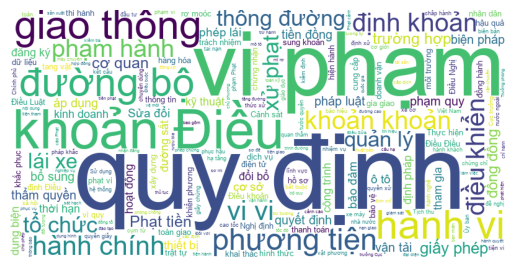

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    font_path="arial.ttf",   # hoặc font Unicode
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()